# Прогнозирование Чемпиона и Индивидуальных наград NBA

### Шаг 1: Загрузка библиотек

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, roc_curve, accuracy_score, log_loss, brier_score_loss, make_scorer
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

plt.rcParams['figure.figsize'] = (10, 6)
def set_dark_theme():
    plt.style.use("dark_background")

    sns.set_style("darkgrid", {
        'axes.facecolor': '#111111',
        'figure.facecolor': '#111111',
        'grid.color': 'white',
        'grid.linestyle': '-',
        'grid.alpha': 0.15
    })

    plt.rcParams.update({
        # Общий фон
        "figure.facecolor": "#111111",
        "axes.facecolor": "#111111",
        "savefig.facecolor": "#111111",

        # Текст
        "text.color": "white",
        "axes.labelcolor": "white",
        "axes.titlecolor": "white",
        "xtick.color": "white",
        "ytick.color": "white",

        # Сетка
        "grid.color": "white",
        "grid.alpha": 0.15,

        # Размеры
        "axes.titlesize": 18,
        "axes.labelsize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,

        # Линии
        "axes.edgecolor": "white",

        # Figure
        "figure.figsize": (10, 6),

        # Шрифт
        "font.family": "sans-serif"
    })
    set_dark_theme()


### Шаг 2: Загрузка датасетов и добавление новых параметров

In [5]:
df_players = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_players_2013_2026_full.csv')
df_teams = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_teams_2013_2026_full.csv')

df_players = df_players[df_players['SEASON_TYPE'] == 'Regular Season'].copy()
df_teams = df_teams[df_teams['SEASON_TYPE'] == 'Regular Season'].copy()

df_players['TS_PCT'] = df_players['PTS'] / (2 * (df_players['FGA'] + 0.44 * df_players['FTA']))
df_players['TS_PCT'] = df_players['TS_PCT'].replace([np.inf, -np.inf], np.nan).fillna(0)

def apply_season_rank(df, cols):
    for col in cols:
        df[f'{col}_RANK'] = df.groupby('SEASON')[col].rank(pct=True)
    return df

player_stats = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'W_PCT', 'PLUS_MINUS', 'TS_PCT']
team_stats = ['W_PCT', 'PLUS_MINUS', 'PTS', 'REB', 'AST', 'FG_PCT']

df_players = apply_season_rank(df_players, player_stats)
df_teams = apply_season_rank(df_teams, team_stats)

df_players = df_players.sort_values(['PLAYER_ID', 'SEASON'])
for stat in ['PTS', 'AST', 'REB', 'STL', 'BLK', 'NBA_FANTASY_PTS', 'MIN']:
    df_players[f'DELTA_{stat}'] = df_players.groupby('PLAYER_ID')[stat].diff().fillna(0)

first_seasons = df_players.groupby('PLAYER_ID')['SEASON'].transform('min')
df_players['IS_ROOKIE_YEAR'] = (df_players['SEASON'] == first_seasons).astype(int)

mvp_winners = {"2013-14": "Kevin Durant", "2014-15": "Stephen Curry", "2015-16": "Stephen Curry", "2016-17": "Russell Westbrook", "2017-18": "James Harden", "2018-19": "Giannis Antetokounmpo", "2019-20": "Giannis Antetokounmpo", "2020-21": "Nikola Jokic", "2021-22": "Nikola Jokić", "2022-23": "Joel Embiid", "2023-24": "Nikola Jokić", "2024-25": "Shai Gilgeous-Alexander"}
dpoy_winners = {"2013-14": "Joakim Noah", "2014-15": "Kawhi Leonard", "2015-16": "Kawhi Leonard", "2016-17": "Draymond Green", "2017-18": "Rudy Gobert", "2018-19": "Rudy Gobert", "2019-20": "Giannis Antetokounmpo", "2020-21": "Rudy Gobert", "2021-22": "Marcus Smart", "2022-23": "Jaren Jackson Jr.", "2023-24": "Rudy Gobert", "2024-25": "Evan Mobley", "2025-26": "Victor Wembanyama"}
mip_winners = {"2013-14": "Goran Dragić", "2014-15": "Jimmy Butler", "2015-16": "CJ McCollum", "2016-17": "Giannis Antetokounmpo", "2017-18": "Victor Oladipo", "2018-19": "Pascal Siakam", "2019-20": "Brandon Ingram", "2020-21": "Julius Randle", "2021-22": "Ja Morant", "2022-23": "Lauri Markkanen", "2023-24": "Tyrese Maxey", "2024-25": "Dyson Daniels", "2025-26": "Nickeil Alexander-Walker"}
roy_winners = {"2013-14": "Michael Carter-Williams", "2014-15": "Andrew Wiggins", "2015-16": "Karl-Anthony Towns", "2016-17": "Malcolm Brogdon", "2017-18": "Ben Simmons", "2018-19": "Luka Doncic", "2019-20": "Ja Morant", "2020-21": "LaMelo Ball", "2021-22": "Scottie Barnes", "2022-23": "Paolo Banchero", "2023-24": "Victor Wembanyama", "2024-25": "Stephon Castle", "2025-26": "Cooper Flagg"}
champions_teams = {"2013-14": "San Antonio Spurs", "2014-15": "Golden State Warriors", "2015-16": "Cleveland Cavaliers", "2016-17": "Golden State Warriors", "2017-18": "Golden State Warriors", "2018-19": "Toronto Raptors", "2019-20": "Los Angeles Lakers", "2020-21": "Milwaukee Bucks", "2021-22": "Golden State Warriors", "2022-23": "Denver Nuggets", "2023-24": "Boston Celtics", "2024-25": "Oklahoma City Thunder"}

def label_target(df, winners_dict, target_col, entity_col):
    df[target_col] = df.apply(lambda x: 1 if winners_dict.get(x['SEASON']) == x[entity_col] else 0, axis=1)
    return df

df_players = label_target(df_players, mvp_winners, 'IS_MVP', 'PLAYER_NAME')
df_players = label_target(df_players, dpoy_winners, 'IS_DPOY', 'PLAYER_NAME')
df_players = label_target(df_players, mip_winners, 'IS_MIP', 'PLAYER_NAME')
df_players = label_target(df_players, roy_winners, 'IS_ROY', 'PLAYER_NAME')
df_teams = label_target(df_teams, champions_teams, 'IS_CHAMPION', 'TEAM_NAME')


team_total_pts = df_players.groupby(['TEAM_ID', 'SEASON'])['PTS'].transform('sum')
df_players['PLAYER_PTS_SHARE'] = df_players['PTS'] / (team_total_pts + 1e-6)

df_teams = df_teams.sort_values(['TEAM_ID', 'SEASON'])
df_teams['W_PCT_IMPROVEMENT'] = df_teams.groupby('TEAM_ID')['W_PCT'].diff().fillna(0)

df_players = df_players.merge(
    df_teams[['TEAM_ID', 'SEASON', 'W_PCT_IMPROVEMENT']],
    on=['TEAM_ID', 'SEASON'],
    how='left'
)

dpoy_features = ['MIN', 'REB', 'TOV', 'STL', 'BLK', 'PLUS_MINUS', 'OREB', 'DREB', 'BLKA', 'PF', 'PFD', 'W', 'W_PCT', 'BLK_RANK', 'STL_RANK', 'PLUS_MINUS_RANK']
players_features = ['PLAYER_PTS_SHARE', 'W', 'W_PCT', 'MIN', 'FG_PCT', 'FG3_PCT', 'FGA', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'W_PCT_RANK', 'PTS', 'PTS_RANK','NBA_FANTASY_PTS_RANK',]
mip_features =['W', 'W_PCT', 'MIN', 'FG_PCT', 'FG3_PCT', 'FGA', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'W_PCT_RANK', 'PTS', 'PTS_RANK', 'DELTA_PTS', 'DELTA_AST', 'DELTA_STL', 'DELTA_BLK', 'DELTA_MIN', 'DELTA_NBA_FANTASY_PTS']

team_features = ['W', 'W_PCT', 'FGM', 'FG_PCT', 'FG3_PCT', 'FG3A', 'REB', 'OREB', 'AST', 'STL', 'BLK', 'TOV', 'PLUS_MINUS', 'PTS', 'PTS_RANK', 'DREB']


delta_cols = [col for col in df_players.columns if col.startswith('DELTA_')]
df_players[delta_cols] = df_players[delta_cols].fillna(0)

df_players = df_players.replace([np.inf, -np.inf], 0)

df_mip_filtered = df_players[(df_players['MIN'] > 15) & (df_players['SEASON'] != '2013-14')].copy()

### Шаг 3: Универсальная функция для обучения и валидации моделей

In [7]:
def train_and_evaluate(df, target, features, task_name):
    warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

    active_features = [f for f in features if f != target and df[f].dtype in ['int64', 'float64']]

    print(f"ЗАДАЧА: {task_name}")

    df_train = df[df[target].notnull() & (df['SEASON'] <= '2024-25')].sort_values('SEASON').copy()
    if df_train.empty:
        print(f"Ошибка: Нет данных для {task_name}")
        return None

    X = df_train[active_features]
    y = df_train[target]

    def scale_by_season(data, feats):
        scaled_df = data.copy()
        scaled_df[feats] = scaled_df[feats].astype(float)
        scaler = StandardScaler()
        for season in data['SEASON'].unique():
            mask = data['SEASON'] == season
            if mask.sum() > 1:
                scaled_df.loc[mask, feats] = scaler.fit_transform(data.loc[mask, feats].values)
            else:
                scaled_df.loc[mask, feats] = 0
        return scaled_df

    X_scaled_full = scale_by_season(df_train, active_features)
    X_scaled = X_scaled_full[active_features]

    pos_weight = (y == 0).sum() / (y == 1).sum() if (y == 1).sum() > 0 else 1
    tscv = TimeSeriesSplit(n_splits=3)

    models_params = {
        'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42), {'C': [0.01, 0.1, 1]}),
        'Random Forest': (RandomForestClassifier(class_weight='balanced', random_state=42), {'n_estimators': [100], 'max_depth': [5, 7]}),
        'XGBoost': (XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss', random_state=42), {'n_estimators': [50, 100], 'learning_rate': [0.05], 'max_depth': [3, 5]}),
        'LightGBM': (LGBMClassifier(importance_type='gain', scale_pos_weight=pos_weight, random_state=42, verbose=-1), {'n_estimators': [50, 100], 'learning_rate': [0.05], 'num_leaves': [15, 31]})
    }

    best_overall_model = None
    best_overall_logloss = float('inf')
    best_overall_name = ""
    performance_metrics = []

    plt.figure(figsize=(10, 6))

    for name, (model, params) in models_params.items():
        grid = GridSearchCV(model, params, scoring='neg_log_loss', cv=tscv, n_jobs=-1)
        grid.fit(X_scaled, y)

        best_m = grid.best_estimator_

        y_prob = best_m.predict_proba(X_scaled)[:, 1]
        y_pred = best_m.predict(X_scaled)

        auc = roc_auc_score(y, y_prob)
        prec = precision_score(y, y_pred, zero_division=0)
        acc = accuracy_score(y, y_pred)
        loss = log_loss(y, y_prob)
        brier = brier_score_loss(y, y_prob)

        performance_metrics.append({
            'Модель': name,
            'AUC': round(auc, 4),
            'Accuracy': round(acc, 4),
            'LogLoss': round(loss, 4),
            'Brier': round(brier, 4),
            'Precision': round(prec, 4)
        })

        fpr, tpr, _ = roc_curve(y, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")


        if loss < best_overall_logloss:
            best_overall_logloss = loss
            best_overall_model = best_m
            best_overall_name = name

    plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC-кривые: {task_name}')
    plt.legend()
    plt.show()

    print(f"\nИтоговые метрики (Ранжирование по LogLoss):")
    res_df = pd.DataFrame(performance_metrics).sort_values(['LogLoss', 'AUC'], ascending=[True, False])

    try:
        display(res_df)
    except:
        print(res_df.to_string(index=False))

    if best_overall_model is not None:
        print(f"\nАнализ важности признаков для лучшей модели ({best_overall_name}):")

        if hasattr(best_overall_model, 'feature_importances_'):
            importances = best_overall_model.feature_importances_
        elif hasattr(best_overall_model, 'coef_'):
            importances = np.abs(best_overall_model.coef_[0])
        else:
            importances = None

        if importances is not None:
            feat_imp = pd.DataFrame({'Feature': active_features, 'Importance': importances})
            feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)
            print(feat_imp.to_string(index=False))

            plt.figure(figsize=(10, 6))
            sns.barplot(data=feat_imp, x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
            plt.title(f'TOP-10 Признаков: {best_overall_name} ({task_name})')
            plt.tight_layout()
            plt.show()

    return best_overall_model

### Шаг 4: Прогнозирование чемпиона NBA

Запускаем процесс обучения на командных данных. Здесь основными признаками выступают кол-во побед (W), имеющий большой отрыв, и реализация бросков (FG_PCT)

ЗАДАЧА: NBA TITLE


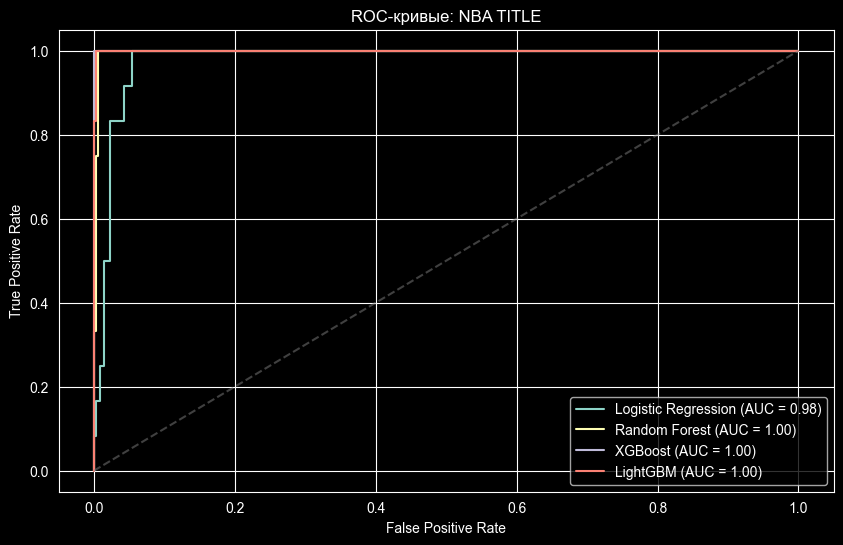


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
3,LightGBM,0.9995,0.9917,0.0418,0.0094,0.8000
2,XGBoost,1.0000,0.9861,0.0443,0.0111,0.7059
1,Random Forest,0.9974,0.9750,0.0519,0.0154,0.5714
0,Logistic Regression,0.9796,0.9278,0.1934,0.0548,0.3158



Анализ важности признаков для лучшей модели (LightGBM):
   Feature  Importance
         W 5062.353877
    FG_PCT 1120.064078
PLUS_MINUS  342.151391
       AST  324.743592
       BLK  243.867138
      FG3A  185.084288
       FGM  166.022056
   FG3_PCT  119.312898
       REB  117.607295
      DREB  114.580507


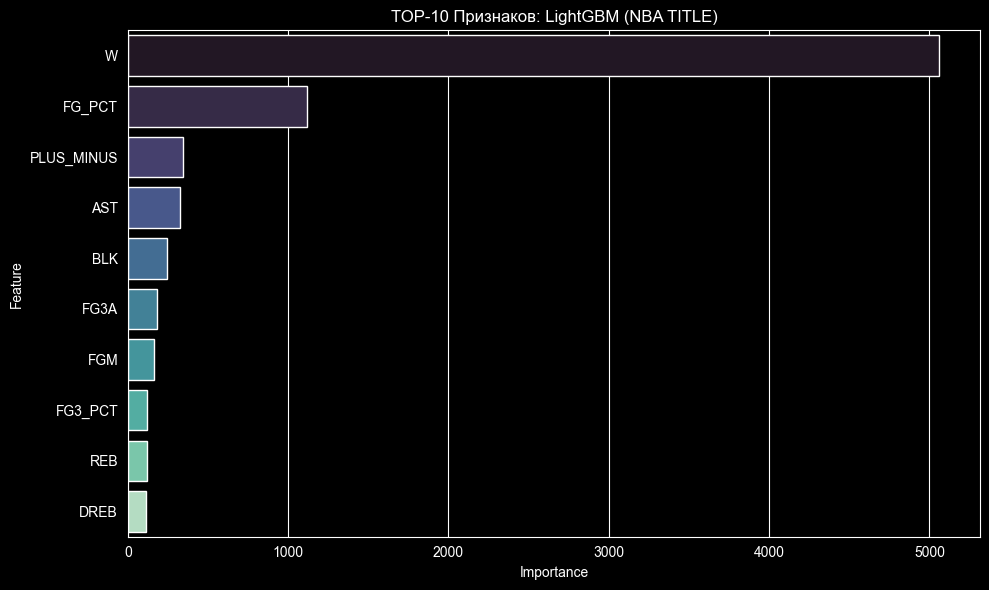

In [8]:
final_nba_title_model = train_and_evaluate(df_teams, 'IS_CHAMPION', team_features, "NBA TITLE")

### Шаг 5: Прогнозирование MVP (Most Valuable Player)

Огромный отрыв за параметром NBA_FANTASY_PTS, который является комбинацией всех основных стат, и что интересно 2-ой по важности показатель - это REB
  (в последние годы награду mvp брали в основном большие игроки и модель это заметила)


Здесь я отсекаю игроков, которые сыграли в серднем меньше 15 минут и в общем меньше 50 игр, эти игоки просто из правил регламента не могут заслужить награду

ЗАДАЧА: MVP (Most Valuable Player)


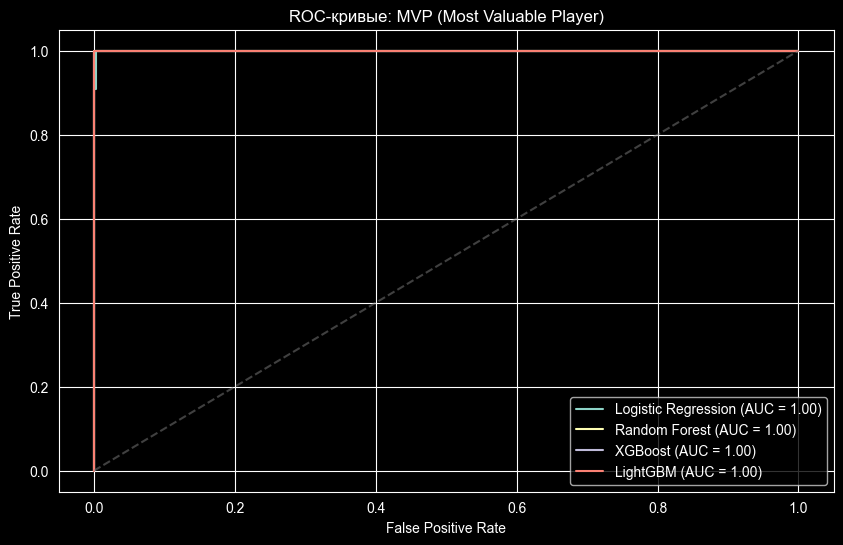


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
3,LightGBM,1.0000,1.0000,0.0001,0.0000,1.0000
1,Random Forest,1.0000,0.9997,0.0051,0.0013,0.9167
2,XGBoost,1.0000,0.9997,0.0054,0.0005,0.9167
0,Logistic Regression,0.9994,0.9923,0.0220,0.0061,0.3143



Анализ важности признаков для лучшей модели (LightGBM):
        Feature    Importance
NBA_FANTASY_PTS 424030.179402
            REB  50389.358657
              W   4837.078927
            PTS   2632.303988
     PLUS_MINUS   1746.149976
         FG_PCT   1337.416771
            TOV   1140.940989
            AST    314.006815
            MIN    296.367893
        FG3_PCT    158.094369


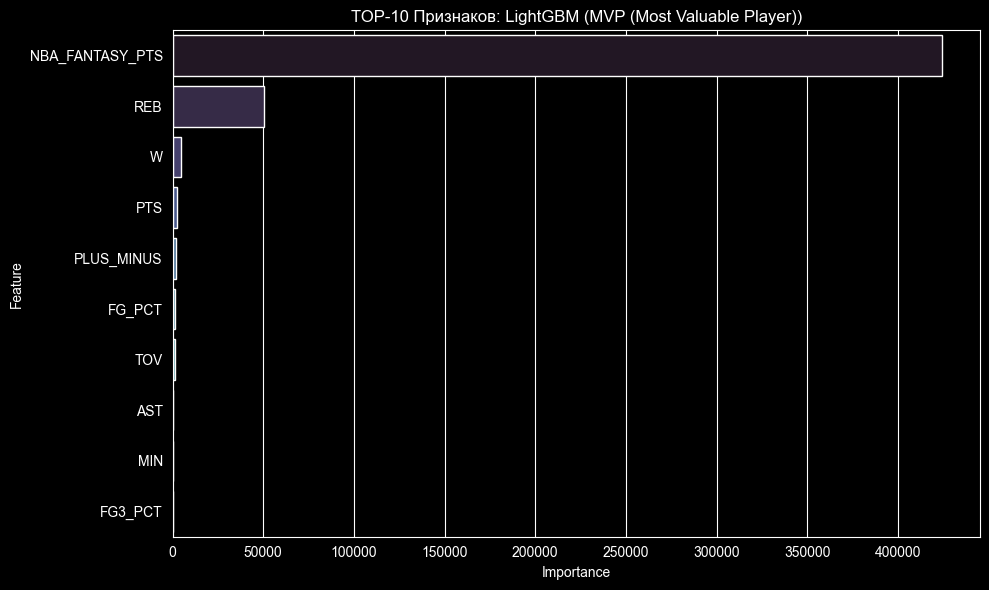

In [9]:
df_mvp = df_players[df_players['MIN'] > 15].copy()
df_mvp = df_mvp[df_mvp['GP'] > 50].copy()
final_mvp_model = train_and_evaluate(df_mvp, 'IS_MVP', players_features, "MVP (Most Valuable Player)")

### Шаг 6: Прогнозирование DPOY (Defensive Player of the Year)

Большой отрыв за параметром PLUS_MINUS, который показывает разницу очков с игроком на площадке, 2-м показателям стал PFD(количество фолов заработанных на игроке)


Здесь я также отсекаю игроков, которые сыграли в серднем меньше 15 минут и в общем меньше 50 игр, эти игоки просто из правил регламента не могут заслужить награду

ЗАДАЧА: DPOY (Defensive Player of the Year)


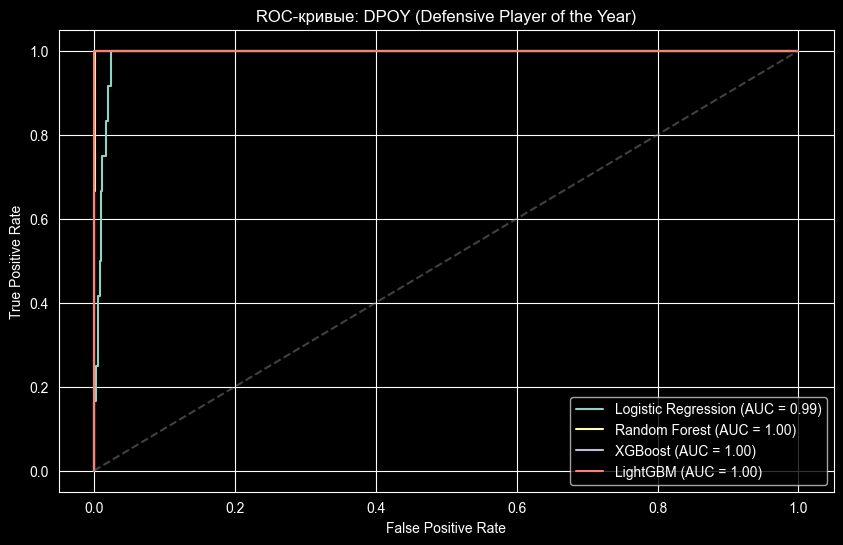


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
3,LightGBM,1.0000,1.0000,0.0002,0.0000,1.0000
2,XGBoost,1.0000,0.9984,0.0087,0.0013,0.7059
1,Random Forest,0.9995,0.9971,0.0176,0.0040,0.5714
0,Logistic Regression,0.9902,0.9610,0.1296,0.0315,0.0902



Анализ важности признаков для лучшей модели (LightGBM):
   Feature    Importance
PLUS_MINUS 276861.291628
       PFD  68316.146449
  STL_RANK  23135.823965
  BLK_RANK  12989.741635
       BLK   7511.664787
       MIN   1811.604273
       REB    897.769306
      OREB    698.697549
       STL    505.920098
       TOV    383.876200


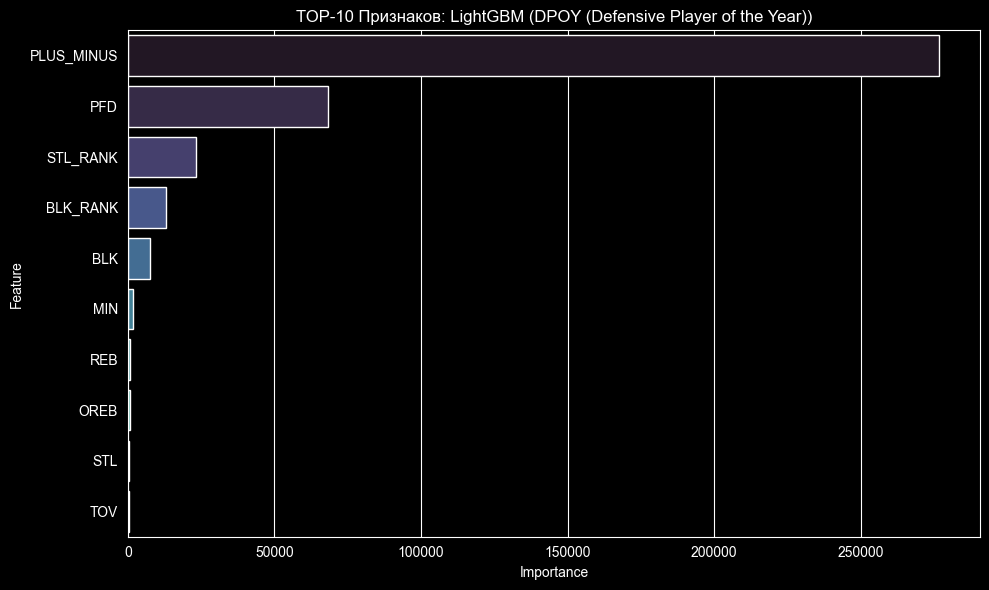

In [10]:
df_dpoy = df_players[df_players['MIN'] > 15].copy()
df_dpoy = df_dpoy[df_dpoy['GP'] > 50].copy()
final_dpoy_model = train_and_evaluate(df_dpoy, 'IS_DPOY', dpoy_features, "DPOY (Defensive Player of the Year)")

### Шаг 7: Прогнозирование MIP (Most Improved Player)

В данной задаче Random Forest показала, что есть несколько важных параметров для предсказания награды

Здесь я также отсекаю игроков, которые сыграли в серднем меньше 10 минут за игру

ЗАДАЧА: MIP (Most Improved Player)


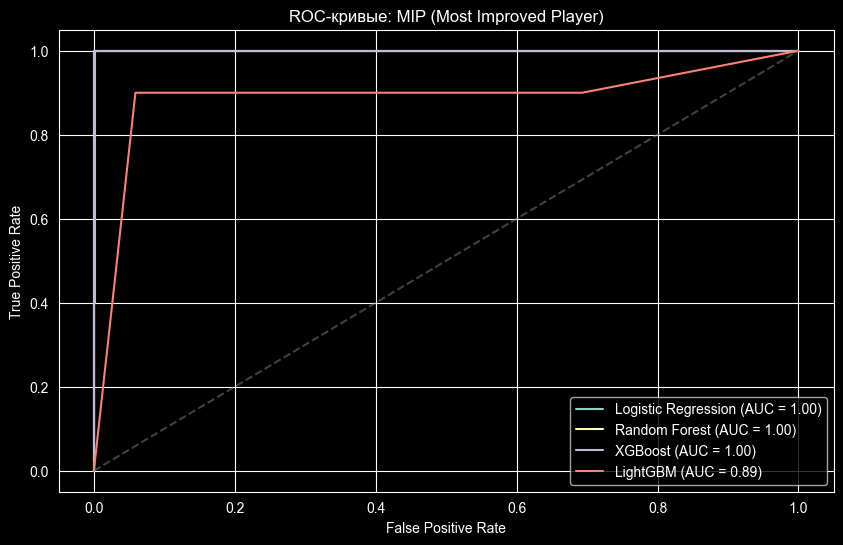


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
1,Random Forest,1.0000,0.9994,0.0059,0.0011,0.7692
2,XGBoost,1.0000,0.9971,0.0099,0.0019,0.4000
0,Logistic Regression,0.9990,0.9899,0.0275,0.0071,0.1613
3,LightGBM,0.8888,0.9410,2.1281,0.0590,0.0288



Анализ важности признаков для лучшей модели (Random Forest):
              Feature  Importance
DELTA_NBA_FANTASY_PTS    0.222941
                  MIN    0.194442
            DELTA_PTS    0.160457
      NBA_FANTASY_PTS    0.090073
             PTS_RANK    0.059292
                  FGA    0.051963
                  TOV    0.051061
            DELTA_AST    0.040974
                  AST    0.028697
                  PTS    0.018868


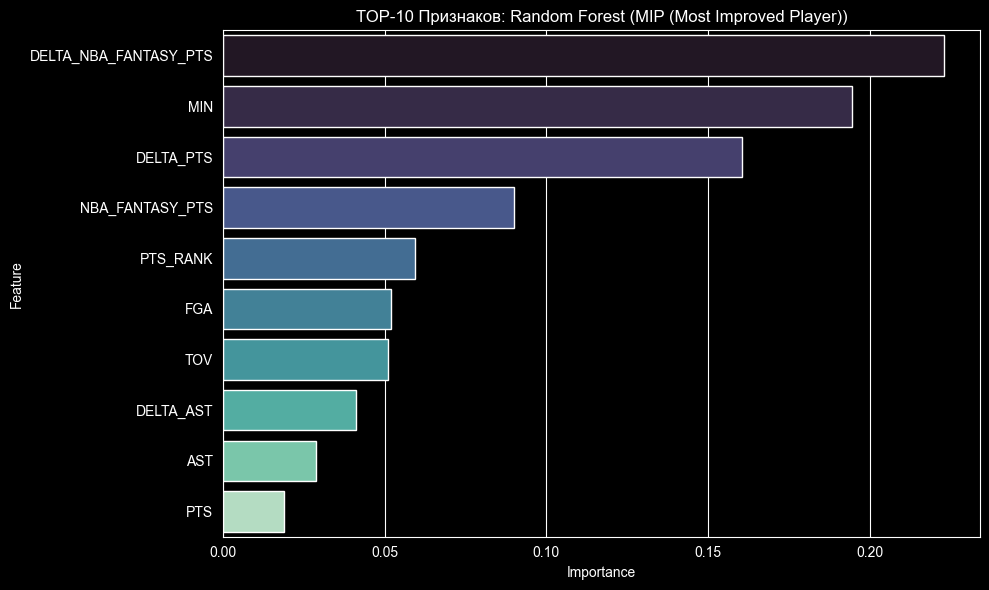

In [11]:
df_mip = df_players[df_players['MIN'] > 10].copy()
final_mip_model = train_and_evaluate(df_mip, 'IS_MIP', mip_features, "MIP (Most Improved Player)")

Я попробовал переобучить модель на этих параметрах и в среднем LogLoss упал

ЗАДАЧА: new MIP (Most Improved Player)


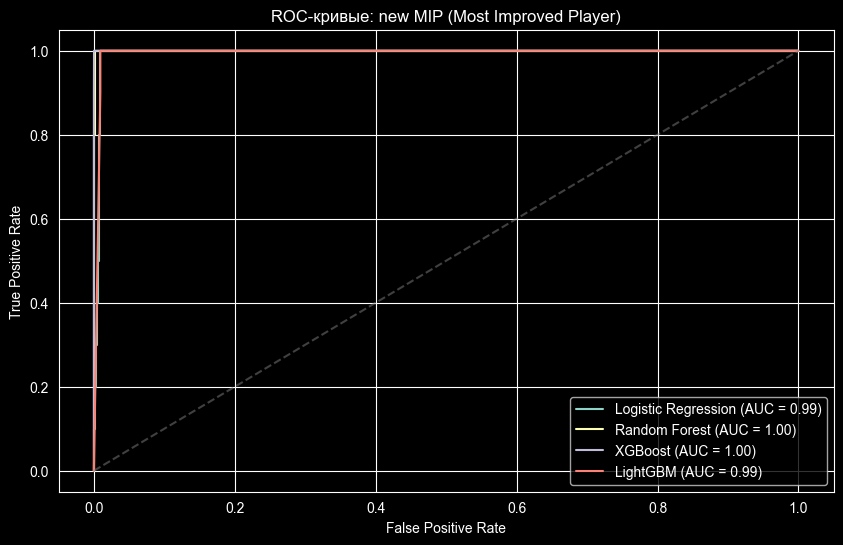


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
2,XGBoost,1.0000,0.9988,0.0071,0.0009,0.6250
1,Random Forest,0.9996,0.9984,0.0071,0.0017,0.5556
0,Logistic Regression,0.9946,0.9765,0.0793,0.0176,0.0763
3,LightGBM,0.9950,0.9909,0.3292,0.0091,0.1754



Анализ важности признаков для лучшей модели (XGBoost):
              Feature  Importance
DELTA_NBA_FANTASY_PTS    0.757070
                  MIN    0.130178
      NBA_FANTASY_PTS    0.049040
            DELTA_PTS    0.028763
                  FGA    0.011957
                  TOV    0.010436
                  AST    0.008595
             PTS_RANK    0.003961
            DELTA_AST    0.000000


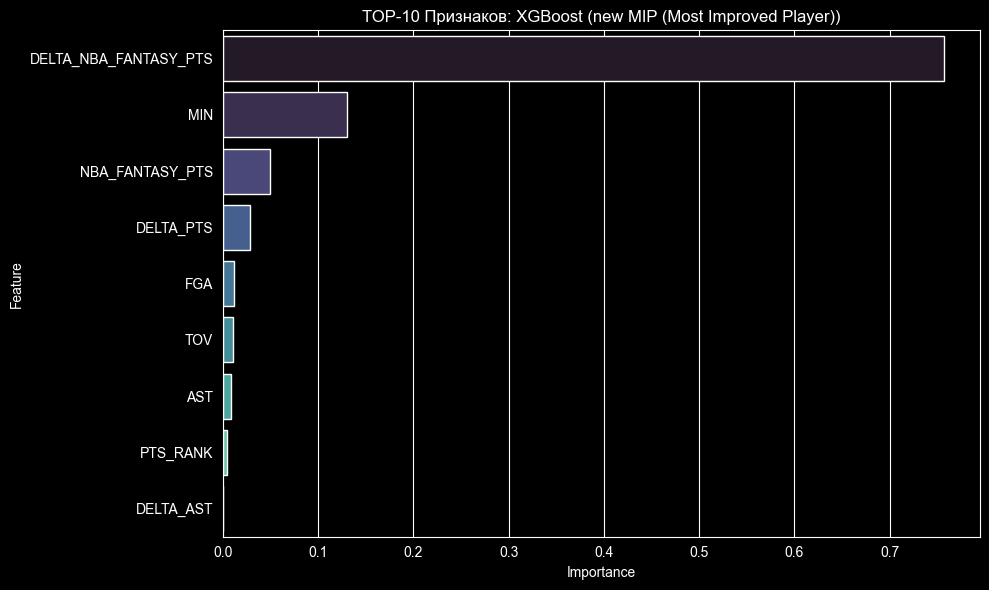

In [12]:
new_mip_features = ['DELTA_NBA_FANTASY_PTS', 'MIN', 'DELTA_PTS', 'NBA_FANTASY_PTS', 'PTS_RANK', 'FGA', 'TOV', 'DELTA_AST', 'AST']
final_mip_model = train_and_evaluate(df_mip, 'IS_MIP', new_mip_features, "new MIP (Most Improved Player)")

### Шаг 8: Прогнозирование ROTY (Rookie of the Year)

NBA_FANTASY_PTS опять стал самым важным параметром для предсказаниия

я выбирал только игроков, которые проводят первый сезон в лиге

ЗАДАЧА: ROTY (Rookie of the Year)


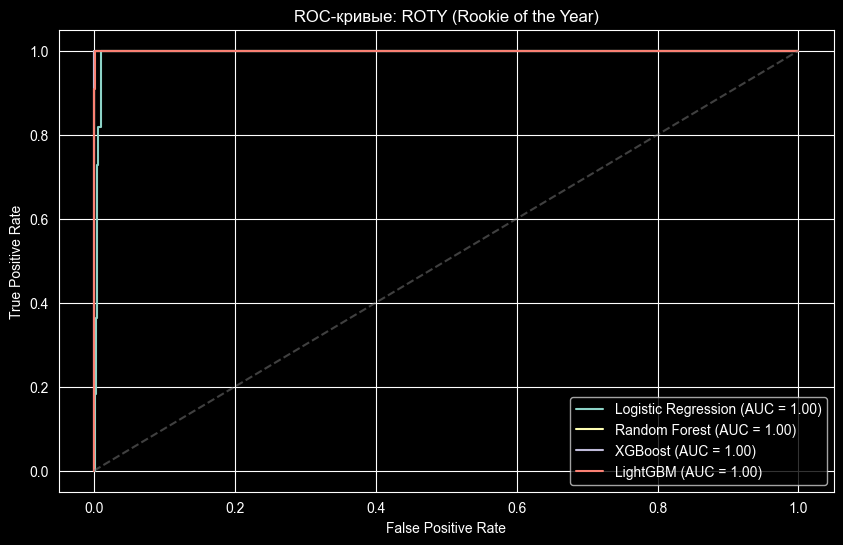


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
2,XGBoost,1.0000,0.9975,0.0096,0.0016,0.7333
1,Random Forest,0.9997,0.9994,0.0107,0.0027,0.9167
3,LightGBM,0.9999,0.9963,0.0141,0.0037,0.6471
0,Logistic Regression,0.9951,0.9769,0.0783,0.0182,0.2292



Анализ важности признаков для лучшей модели (XGBoost):
         Feature  Importance
 NBA_FANTASY_PTS    0.817561
             FGA    0.035785
             AST    0.029465
      W_PCT_RANK    0.013335
           W_PCT    0.011858
             MIN    0.011724
PLAYER_PTS_SHARE    0.011706
             TOV    0.009263
             REB    0.009255
        PTS_RANK    0.008830


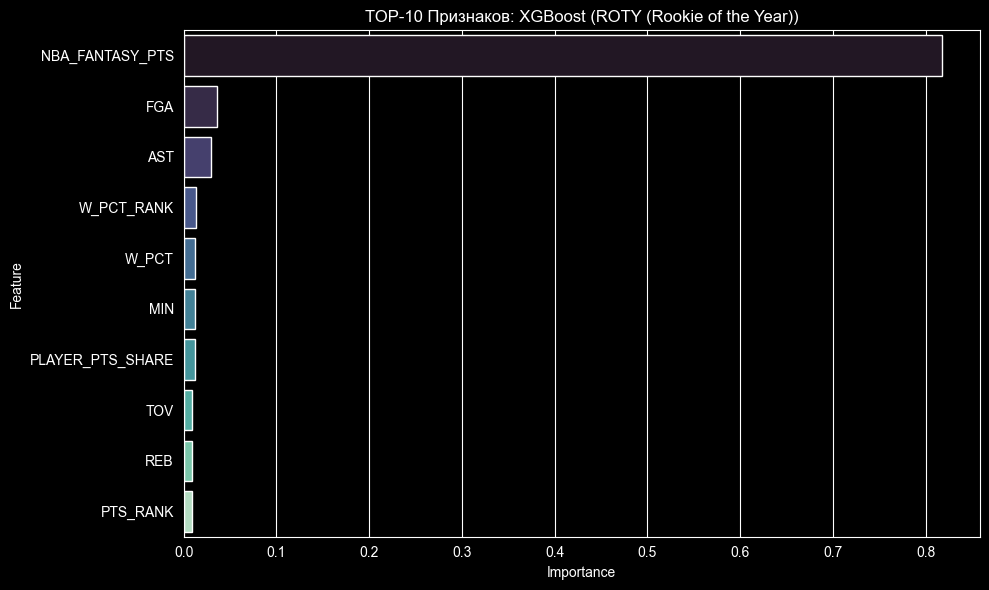

In [13]:
df_rookies = df_players[df_players['IS_ROOKIE_YEAR'] == 1].copy()
final_roty_model = train_and_evaluate(df_rookies, 'IS_ROY', players_features, "ROTY (Rookie of the Year)")

### Шаг 9: Вероятные победиетли по каждой из наград

Предсказания лучших моделей для кажной из наград:

ПРОГНОЗ: NBA Champion (Сезон 2025-26)


,TEAM_NAME,Шанс на победу (%)
556,Oklahoma City Thunder,26.99
544,Detroit Pistons,22.36
555,New York Knicks,12.04
543,Denver Nuggets,11.75
562,San Antonio Spurs,6.24


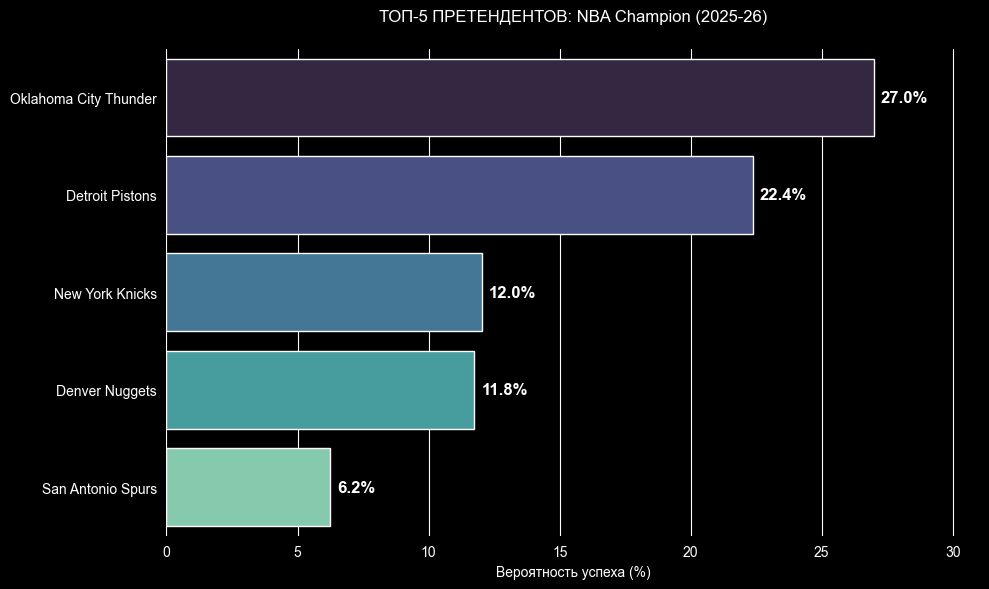


ПРОГНОЗ: MVP (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
3161,Nikola Jokić,28.97
4648,Shai Gilgeous-Alexander,5.07
6542,Victor Wembanyama,3.37
4876,Luka Dončić,0.22
4064,Alex Caruso,0.02


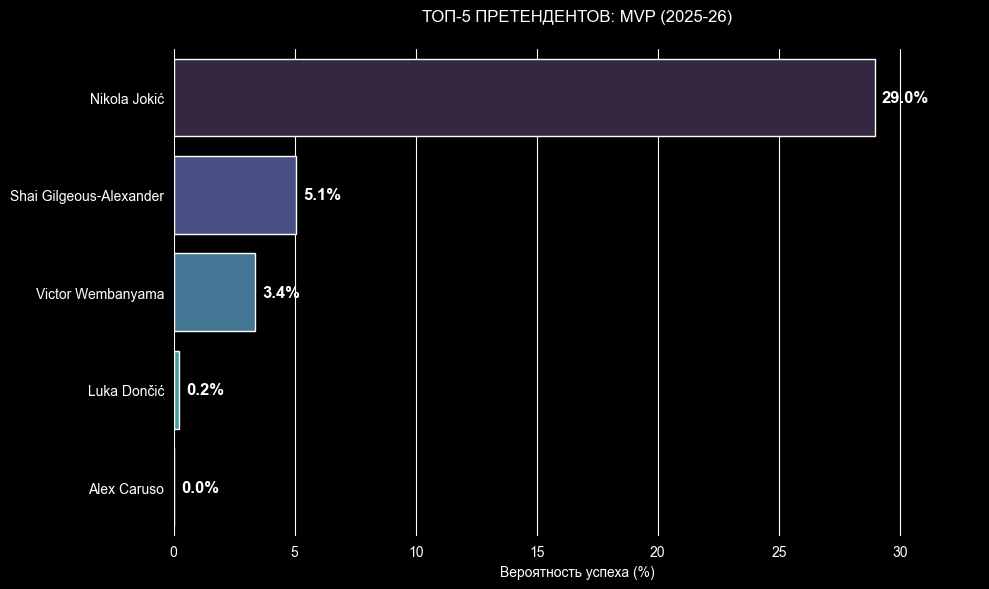


ПРОГНОЗ: DPOY (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
6542,Victor Wembanyama,16.60
6114,Evan Mobley,1.27
6870,Cooper Flagg,0.43
4367,Dillon Brooks,0.41
4244,Bam Adebayo,0.27


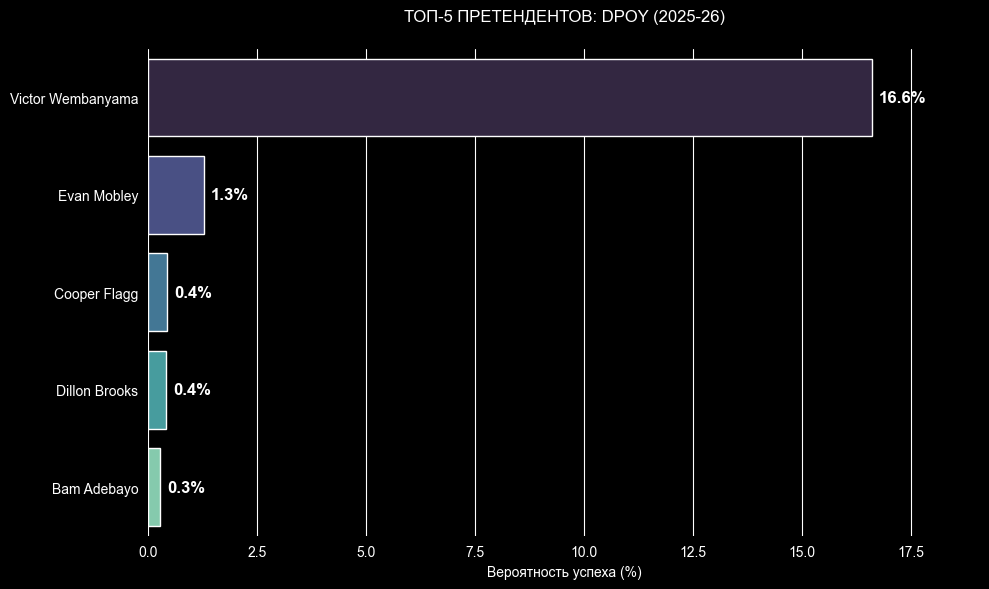


ПРОГНОЗ: MIP (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
5200,Nickeil Alexander-Walker,72.41
5528,Deni Avdija,56.71
5238,Kevin Porter Jr.,27.85
4161,Lauri Markkanen,26.64
6375,Ryan Rollins,23.84


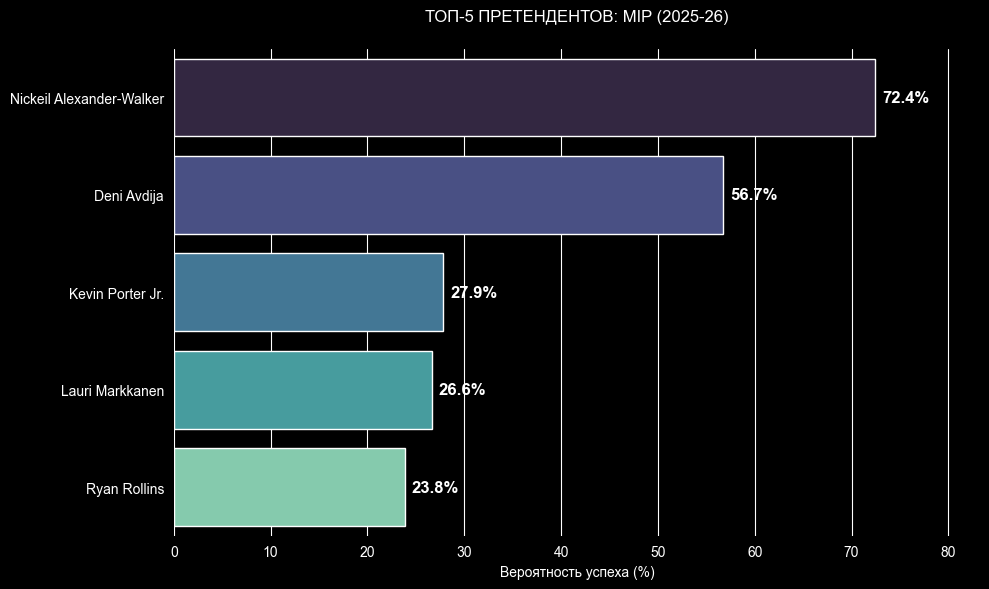


ПРОГНОЗ: ROTY (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
6870,Cooper Flagg,19.320000
6872,VJ Edgecombe,17.629999
6878,Derik Queen,3.370000
6871,Dylan Harper,1.290000
6874,Jeremiah Fears,1.190000


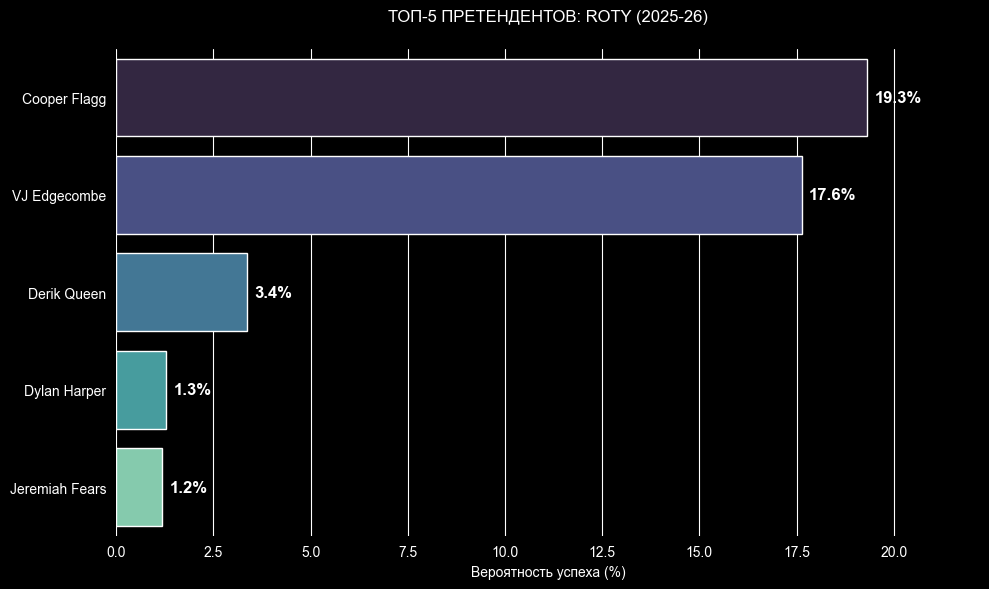


Предсказания, которые яв-ся самыми близкими к реальности по моему мнению:

ПРОГНОЗ: NBA Champion (Сезон 2025-26)


,TEAM_NAME,Шанс на победу (%)
556,Oklahoma City Thunder,72.57
544,Detroit Pistons,39.34
543,Denver Nuggets,36.50
562,San Antonio Spurs,34.10
555,New York Knicks,32.00


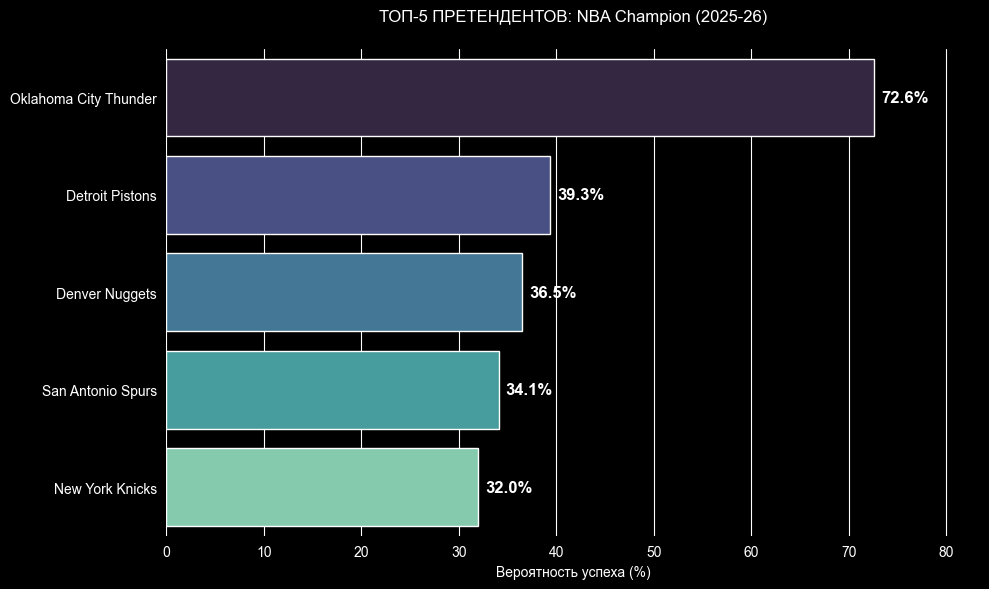


ПРОГНОЗ: MVP (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
4648,Shai Gilgeous-Alexander,78.919998
3161,Nikola Jokić,45.049999
6542,Victor Wembanyama,13.320000
4876,Luka Dončić,8.270000
5594,Tyrese Maxey,0.990000


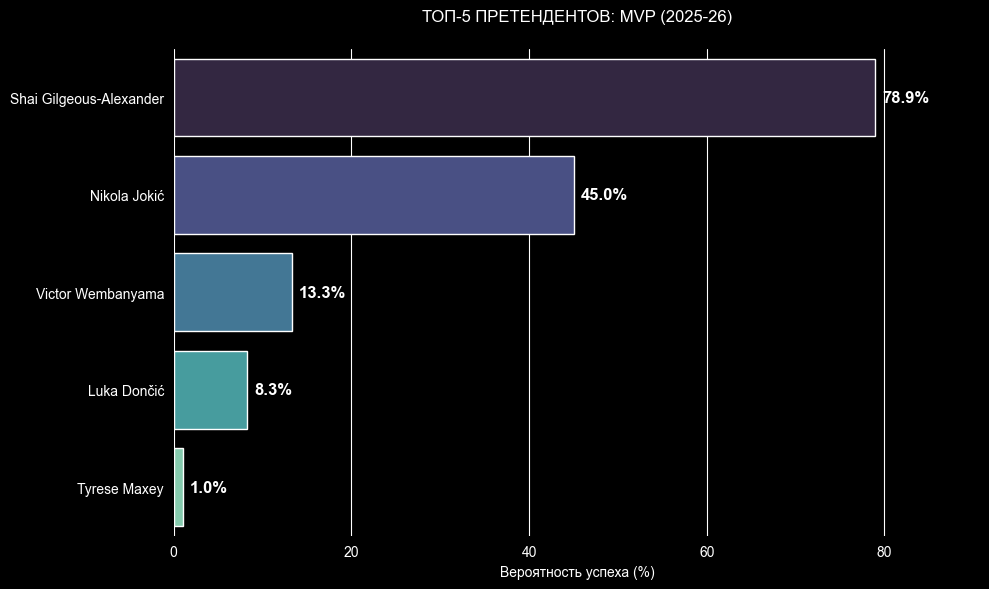


ПРОГНОЗ: DPOY (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
6114,Evan Mobley,66.67
6542,Victor Wembanyama,51.55
6030,Scottie Barnes,49.69
6062,Alperen Sengun,42.85
6258,Chet Holmgren,40.57


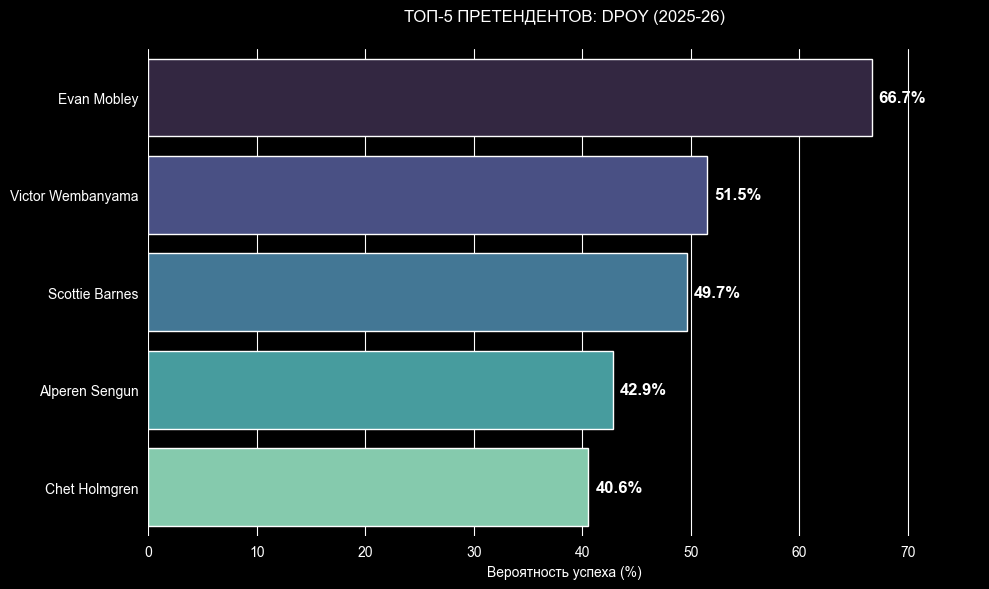


ПРОГНОЗ: MIP (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
5200,Nickeil Alexander-Walker,72.41
5528,Deni Avdija,56.71
5238,Kevin Porter Jr.,27.85
4161,Lauri Markkanen,26.64
6375,Ryan Rollins,23.84


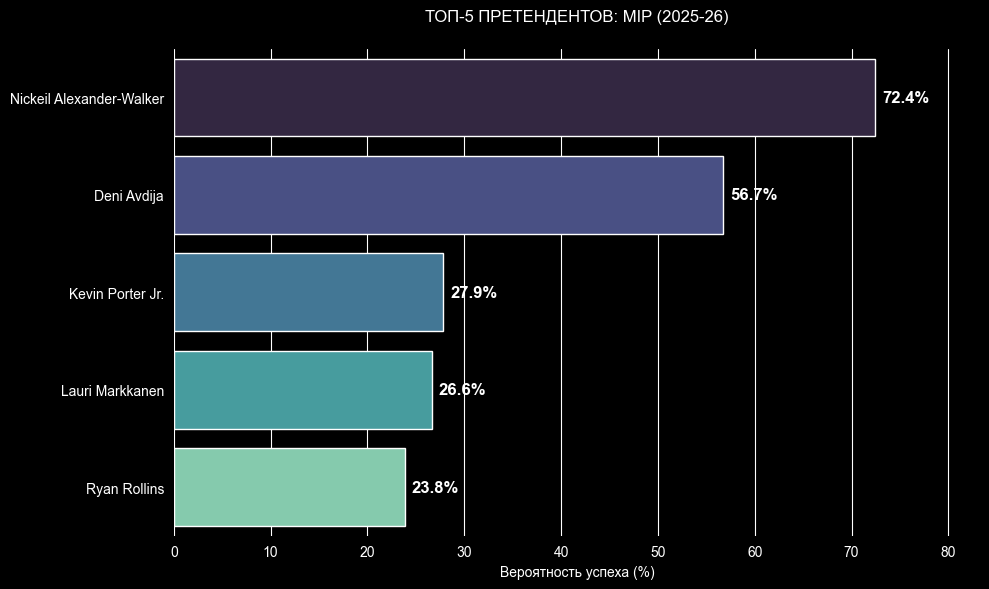


ПРОГНОЗ: ROTY (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
6870,Cooper Flagg,19.320000
6872,VJ Edgecombe,17.629999
6878,Derik Queen,3.370000
6871,Dylan Harper,1.290000
6874,Jeremiah Fears,1.190000


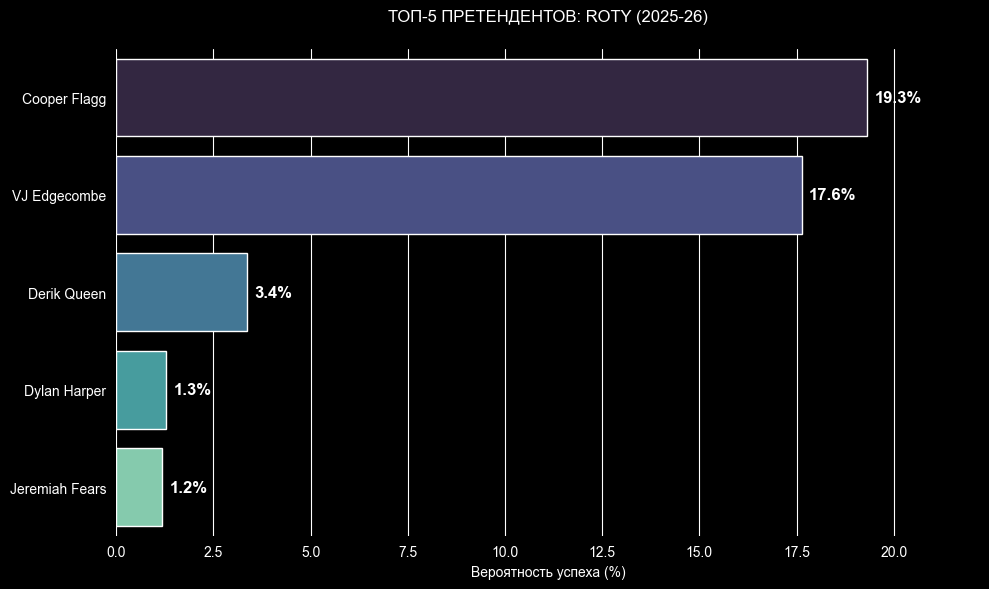

In [33]:
def predict_and_show_probabilities(df, target, features, entity_col, task_name, model):
    print(f"\nПРОГНОЗ: {task_name} (Сезон 2025-26)")

    train_df = df[df['SEASON'] < '2025-26'].dropna(subset=features + [target])
    future_df = df[df['SEASON'] == '2025-26'].dropna(subset=features).copy()

    if future_df.empty:
        print(f"Нет данных для прогноза {task_name} на сезон 2025-26.")
        return

    X_train = train_df[features]
    y_train = train_df[target]
    X_future = future_df[features]

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
    X_future_scaled = pd.DataFrame(scaler.transform(X_future), columns=features)

    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(X_future_scaled)[:, 1]
    future_df['Шанс на победу (%)'] = (probs * 100).round(2)

    top_candidates = future_df.sort_values('Шанс на победу (%)', ascending=False).head(5)
    display(top_candidates[[entity_col, 'Шанс на победу (%)']])

    ax = sns.barplot(
        data=top_candidates,
        x='Шанс на победу (%)',
        y=entity_col,
        palette='mako',
        hue=entity_col,
        legend=False
    )
    for i in ax.containers:
        ax.bar_label(i, padding=5, fmt='%.1f%%', fontsize=12, fontweight='bold')
    plt.title(f'ТОП-5 ПРЕТЕНДЕНТОВ: {task_name} (2025-26)', pad=20)
    plt.xlabel('Вероятность успеха (%)')
    plt.ylabel('')
    plt.xlim(0, max(top_candidates['Шанс на победу (%)']) * 1.15)
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    plt.show()


print("Предсказания лучших моделей для кажной из наград:")
predict_and_show_probabilities(df_teams, 'IS_CHAMPION', team_features, 'TEAM_NAME', 'NBA Champion',
    LGBMClassifier(n_estimators=100, learning_rate=0.05, importance_type='gain', random_state=42, verbose=-1))

predict_and_show_probabilities(df_mvp, 'IS_MVP', players_features, 'PLAYER_NAME', 'MVP',
    LGBMClassifier(n_estimators=100, learning_rate=0.05, importance_type='gain', random_state=42, verbose=-1))

predict_and_show_probabilities(df_dpoy, 'IS_DPOY', dpoy_features, 'PLAYER_NAME', 'DPOY',
    LGBMClassifier(n_estimators=100, learning_rate=0.05, importance_type='gain', random_state=42, verbose=-1))

predict_and_show_probabilities(df_mip, 'IS_MIP', mip_features, 'PLAYER_NAME', 'MIP',
    RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))

predict_and_show_probabilities(df_rookies, 'IS_ROY', players_features, 'PLAYER_NAME', 'ROTY',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, eval_metric='logloss'))



print(f"\nПредсказания, которые яв-ся самыми близкими к реальности по моему мнению:")

predict_and_show_probabilities(df_teams, 'IS_CHAMPION', team_features, 'TEAM_NAME', 'NBA Champion',
    RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))

predict_and_show_probabilities(df_mvp, 'IS_MVP', players_features, 'PLAYER_NAME', 'MVP',
     XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, eval_metric='logloss'))

predict_and_show_probabilities(df_dpoy, 'IS_DPOY', dpoy_features, 'PLAYER_NAME', 'DPOY',
    RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))

predict_and_show_probabilities(df_mip, 'IS_MIP', mip_features, 'PLAYER_NAME', 'MIP',
    RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))

predict_and_show_probabilities(df_rookies, 'IS_ROY', players_features, 'PLAYER_NAME', 'ROTY',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, eval_metric='logloss'))

